#  Anomaly Detection using Isolation Forest

Isolation Forest is an Ensemble Learning Technique.

Just like Random Forest,
it creates multiple decision trees.

But its purpose is different:
Instead of classification or regression,
it isolates anomalies.


## 🔹 Why the Name "Isolation Forest"?

Two words:
Isolation + Forest

Isolation → Separating data points
Forest → Collection of many trees

So,
Isolation Forest = Group of trees that isolate data points.


## 🔹 Connection with Random Forest

You have studied Random Forest.

Random Forest:
- Many decision trees
- Used for classification/regression
- Final output = majority voting or averaging

Isolation Forest:
- Many random trees (called Isolation Trees)
- Used for anomaly detection
- Goal = isolate rare points quickly

# 🧠 Core Idea Behind Isolation Forest

Key Observation:

1. Normal data points exist in dense regions.
2. Anomalies exist in sparse regions.

Dense region → Many similar points nearby  
Sparse region → Few or isolated points

Isolation Forest uses this property.

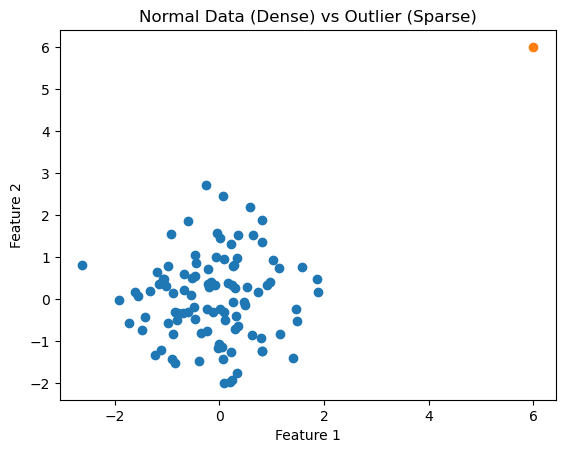

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Normal data (dense cluster)
normal_data = np.random.randn(100, 2)

# Outlier (far away)
outlier = np.array([[6, 6]])

plt.scatter(normal_data[:,0], normal_data[:,1])
plt.scatter(outlier[:,0], outlier[:,1])
plt.title("Normal Data (Dense) vs Outlier (Sparse)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 🔹 What Does Isolation Mean?

Isolation means:
Separating one data point from others
using random splits.

If a point is an anomaly,
it will be easier to isolate.

If a point is normal,
it will take more splits to isolate.

## How Isolation Tree Works (Step-by-Step)

## 🔹 Step 1: Random Feature Selection

Select a random feature (for example Feature 1).

## 🔹 Step 2: Random Split Value

Choose a random split value between
minimum and maximum of that feature.

## 🔹 Step 3: Split the Data

Data gets divided into two parts.

Repeat this process recursively
until each data point is isolated.

## 🔹 What is Path Length? (imp)

Path length = Number of splits required
to isolate a data point in a tree.

Short Path Length → Likely anomaly  
Long Path Length → Likely normal




Anomaly Score Concept

After building multiple trees:

We calculate:
Average path length for each point.

Then compute anomaly score.

Score close to 1 → Strong anomaly  
Score close to 0 → Normal point

In [2]:
from sklearn.ensemble import IsolationForest

# Create model
model = IsolationForest(contamination=0.05, random_state=42)

# Fit model
model.fit(normal_data)

# Predict
predictions = model.predict(np.vstack([normal_data, outlier]))

print(predictions)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1 -1]


Output Interpretation:

-1 → Anomaly  
 1 → Normal